<a href="https://colab.research.google.com/github/Nicolascollao27/Nicol-s-Collao/blob/main/An%C3%A1lisis_Employee_compensation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Dataset

In [ ]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/employee_compensation.csv'
df = pd.read_csv(path, sep="," )

df.head()

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female


2) Primeras 10 Filas

In [ ]:
df.head(10)

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female
5,81246.0,4.0,21.0,2.8,Bachelor,Engineering,West,Junior,Male
6,71494.0,4.0,23.0,2.4,Bachelor,Engineering,South,Junior,Male
7,78189.0,3.0,21.0,3.5,Master,Finance,East,Junior,NaN
8,67204.0,0.0,21.0,3.5,Master,Marketing,East,Junior,Female
9,59776.0,4.0,24.0,NaN,Bachelor,HR,East,Junior,Female


3) Depuración de datos

In [ ]:
# Ver información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             9897 non-null   float64
 1   Years_Experience   9695 non-null   float64
 2   Age                9797 non-null   float64
 3   Performance_Score  9497 non-null   float64
 4   Education_Level    9594 non-null   object 
 5   Department         9795 non-null   object 
 6   Region             9699 non-null   object 
 7   Job_Level          10100 non-null  object 
 8   Gender             9599 non-null   object 
dtypes: float64(4), object(5)
memory usage: 710.3+ KB


In [ ]:
# Ver tipos de datos por columna
df.dtypes

,0
Salary,float64
Years_Experience,float64
Age,float64
Performance_Score,float64
Education_Level,object
Department,object
Region,object
Job_Level,object
Gender,object


In [ ]:
# Valores faltantes por columna
missing_values = df.isnull().sum()

# Porcentaje de valores faltantes
missing_percent = (df.isnull().sum() / len(df)) * 100

# Tabla resumen de valores faltantes
missing_report = pd.DataFrame({
    'Valores faltantes': missing_values,
    'Porcentaje (%)': missing_percent
})

missing_report

,Valores faltantes,Porcentaje (%)
Salary,203,2.009901
Years_Experience,405,4.009901
Age,303,3.000000
Performance_Score,603,5.970297
Education_Level,506,5.009901
Department,305,3.019802
Region,401,3.970297
Job_Level,0,0.000000
Gender,501,4.960396


In [ ]:
# Verificar filas duplicadas
duplicados = df.duplicated().sum()

print(f"Cantidad de filas duplicadas: {duplicados}")

Cantidad de filas duplicadas: 97


In [ ]:
# Mostrar filas duplicadas si existen
df[df.duplicated()]

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
10000,133640.0,11.0,38.0,1.2,PhD,Sales,North,Senior,Male
10001,81789.0,7.0,27.0,4.6,Bachelor,Marketing,South,Mid,Female
10002,94596.0,10.0,31.0,1.6,Bachelor,Finance,North,Mid,Male
10003,87099.0,3.0,26.0,2.7,Bachelor,Engineering,North,Junior,Male
10004,135357.0,14.0,33.0,3.3,Bachelor,Engineering,West,Senior,Male
...,...,...,...,...,...,...,...,...,...
10095,74331.0,1.0,24.0,4.9,Master,Sales,South,Junior,Female
10096,135199.0,14.0,41.0,4.4,PhD,Sales,West,Senior,Female
10097,96435.0,5.0,NaN,2.6,NaN,Engineering,East,Mid,Male
10098,74207.0,1.0,26.0,NaN,Master,Marketing,East,Junior,Male


In [ ]:
print("Reporte de valores faltantes:")
print(missing_report)

print("\nCantidad de duplicados:")
print(duplicados)

Reporte de valores faltantes:
                   Valores faltantes  Porcentaje (%)
Salary                           203        2.009901
Years_Experience                 405        4.009901
Age                              303        3.000000
Performance_Score                603        5.970297
Education_Level                  506        5.009901
Department                       305        3.019802
Region                           401        3.970297
Job_Level                          0        0.000000
Gender                           501        4.960396

Cantidad de duplicados:
97


In [ ]:
df_clean = df.copy()

In [ ]:
# Eliminar duplicados
df_clean = df_clean.drop_duplicates()

# Verificar resultado
print("Filas después de eliminar duplicados:", df_clean.shape[0])
print("Duplicados restantes:", df_clean.duplicated().sum())

Filas después de eliminar duplicados: 10003
Duplicados restantes: 0


In [ ]:
import numpy as np

Estandarización

In [ ]:
# Columnas categóricas
categorical_cols = ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']

# Limpiar espacios y estandarizar formato
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# Reemplazar posibles "Nan" generados por astype(str)
df_clean = df_clean.replace('Nan', np.nan)

# Revisar valores únicos después de limpiar
for col in categorical_cols:
    print(f"\nValores únicos en {col}:")
    print(df_clean[col].unique())


Valores únicos en Education_Level:
['Bachelor' 'Master' 'Phd' nan]

Valores únicos en Department:
['Sales' 'Finance' 'Hr' 'Marketing' 'Engineering' nan]

Valores únicos en Region:
['East' 'West' 'South' 'North' nan]

Valores únicos en Job_Level:
['Junior' 'Mid' 'Senior']

Valores únicos en Gender:
['Male' 'Female' nan]


In [ ]:
# Columnas numéricas
numeric_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score']

# Imputar valores faltantes con la mediana
for col in numeric_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)
    print(f"{col}: valores faltantes imputados con mediana = {median_value}")

Salary: valores faltantes imputados con mediana = 91732.0
Years_Experience: valores faltantes imputados con mediana = 6.0
Age: valores faltantes imputados con mediana = 29.0
Performance_Score: valores faltantes imputados con mediana = 3.0


In [ ]:
# Imputar categóricas con la moda
for col in categorical_cols:
    mode_value = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_value)
    print(f"{col}: valores faltantes imputados con moda = {mode_value}")

Education_Level: valores faltantes imputados con moda = Bachelor
Department: valores faltantes imputados con moda = Engineering
Region: valores faltantes imputados con moda = South
Job_Level: valores faltantes imputados con moda = Mid
Gender: valores faltantes imputados con moda = Female


In [ ]:
# Revisar valores faltantes finales
missing_final = df_clean.isnull().sum()

print("Valores faltantes después de la limpieza:")
print(missing_final)

print("\nDuplicados después de la limpieza:")
print(df_clean.duplicated().sum())

print("\nDimensión final del dataset:")
print(df_clean.shape)

Valores faltantes después de la limpieza:
Salary               0
Years_Experience     0
Age                  0
Performance_Score    0
Education_Level      0
Department           0
Region               0
Job_Level            0
Gender               0
dtype: int64

Duplicados después de la limpieza:
3

Dimensión final del dataset:
(10003, 9)


In [ ]:
df_clean.describe()

,Salary,Years_Experience,Age,Performance_Score
count,10003.000000,10003.000000,10003.000000,10003.000000
mean,95688.100070,6.791463,29.455363,3.026362
std,30351.421556,5.579057,6.750686,1.759577
min,5342.000000,-10.000000,1.000000,-1.000000
25%,77300.000000,3.000000,25.000000,2.100000
50%,91732.000000,6.000000,29.000000,3.000000
75%,111451.000000,10.000000,33.000000,3.900000
max,394249.000000,78.000000,119.000000,99.000000


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10003 entries, 0 to 10037
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             10003 non-null  float64
 1   Years_Experience   10003 non-null  float64
 2   Age                10003 non-null  float64
 3   Performance_Score  10003 non-null  float64
 4   Education_Level    10003 non-null  object 
 5   Department         10003 non-null  object 
 6   Region             10003 non-null  object 
 7   Job_Level          10003 non-null  object 
 8   Gender             10003 non-null  object 
dtypes: float64(4), object(5)
memory usage: 781.5+ KB


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set(style="whitegrid")

# Revisar columnas disponibles
df_clean.columns

Index(['Salary', 'Years_Experience', 'Age', 'Performance_Score',
       'Education_Level', 'Department', 'Region', 'Job_Level', 'Gender'],
      dtype='object')

 Histograma del salario

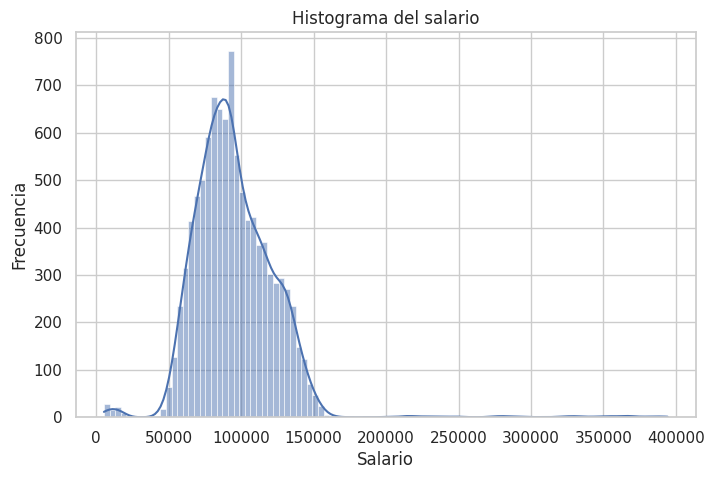

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Salary'], bins=100, kde=True)
plt.title('Histograma del salario')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

La distribución del salario se concentra principalmente entre 50.000 y 150.000, con una mayor frecuencia alrededor de 90.000. Sin embargo, se observan valores extremos tanto en la parte baja como en la parte alta, lo que sugiere la presencia de outliers que deberían revisarse antes de continuar con el análisis.

Boxplot del salario por nivel de cargo

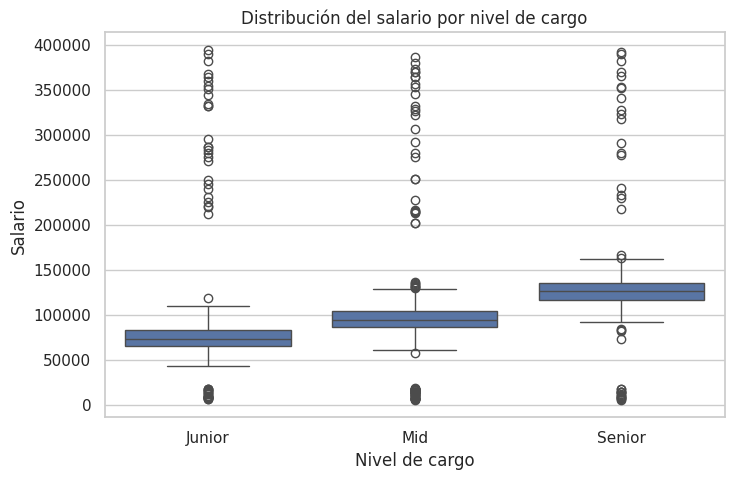

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Job_Level', y='Salary')
plt.title('Distribución del salario por nivel de cargo')
plt.xlabel('Nivel de cargo')
plt.ylabel('Salario')
plt.show()

El boxplot muestra una relación coherente entre nivel de cargo y salario, ya que los cargos Senior presentan una mediana salarial mayor que los Mid y Junior. No obstante, se observan numerosos valores atípicos, especialmente salarios extremadamente altos y bajos, lo que indica que la variable Salary requiere una revisión o tratamiento de outliers antes del análisis posterior.

Dispersión: años de experiencia vs salario

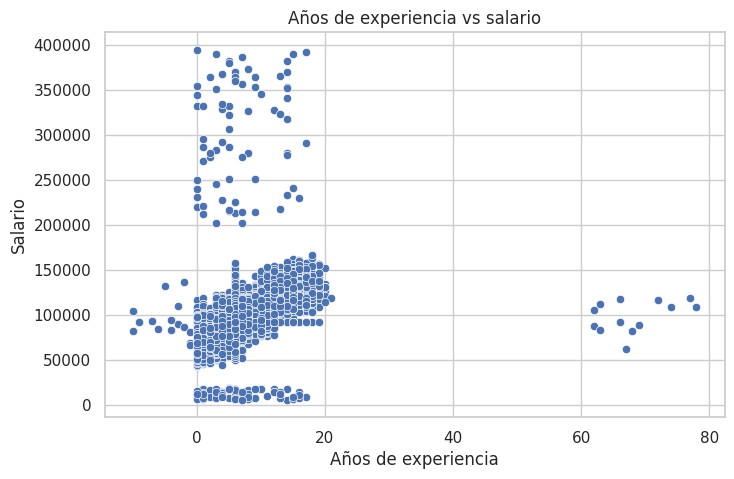

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='Years_Experience', y='Salary')
plt.title('Años de experiencia vs salario')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.show()

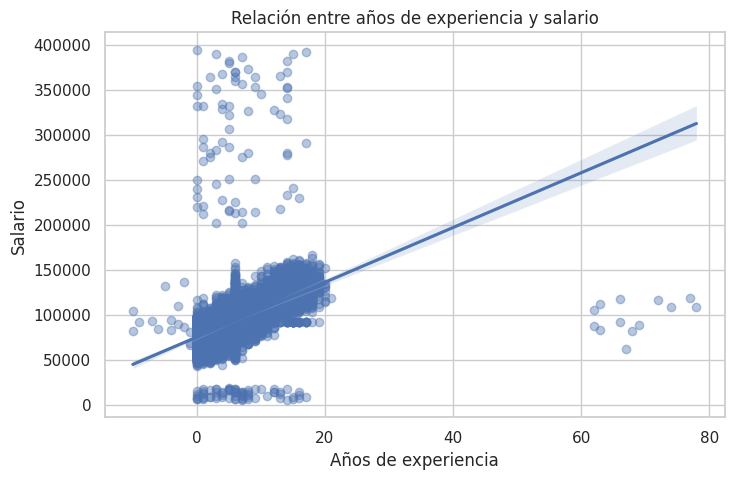

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(data=df_clean, x='Years_Experience', y='Salary', scatter_kws={'alpha':0.4})
plt.title('Relación entre años de experiencia y salario')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.show()

El gráfico de dispersión sugiere una relación positiva entre años de experiencia y salario, ya que la nube principal de datos muestra que los salarios tienden a aumentar a medida que aumenta la experiencia. Sin embargo, existen valores anómalos, como experiencia negativa o experiencia superior a 60 años, que no son razonables y pueden sesgar la línea de tendencia. Por lo tanto, esta relación debe interpretarse con cautela hasta depurar los datos.

Salario promedio por departamento

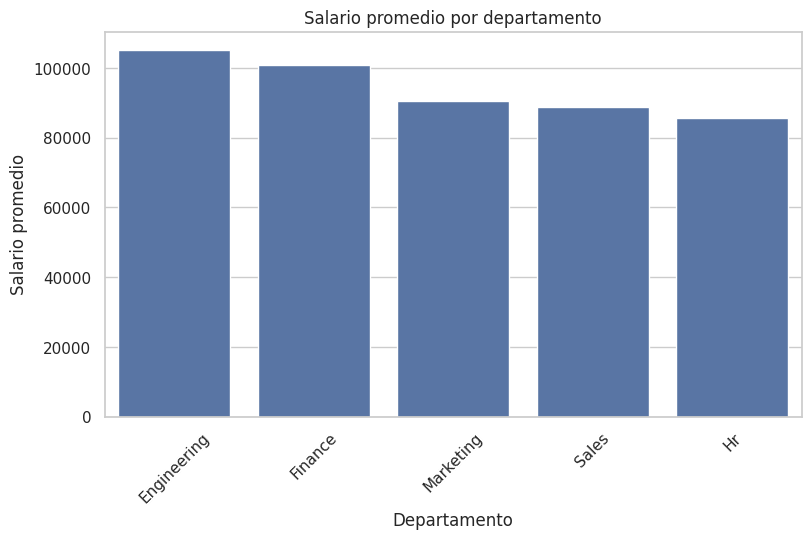

In [ ]:
salary_department = df_clean.groupby('Department')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=salary_department.index, y=salary_department.values)
plt.title('Salario promedio por departamento')
plt.xlabel('Departamento')
plt.ylabel('Salario promedio')
plt.xticks(rotation=45)
plt.show()

El gráfico de barras muestra que Engineering tiene el mayor salario promedio, seguido por Finance. En cambio, HR presenta el menor salario promedio. Esta diferencia puede reflejar distintas estructuras salariales por departamento. Sin embargo, como se detectaron valores extremos en Salary, los promedios podrían estar sesgados, por lo que sería recomendable comparar también la mediana salarial por departamento.

Mapa de calor de correlaciones

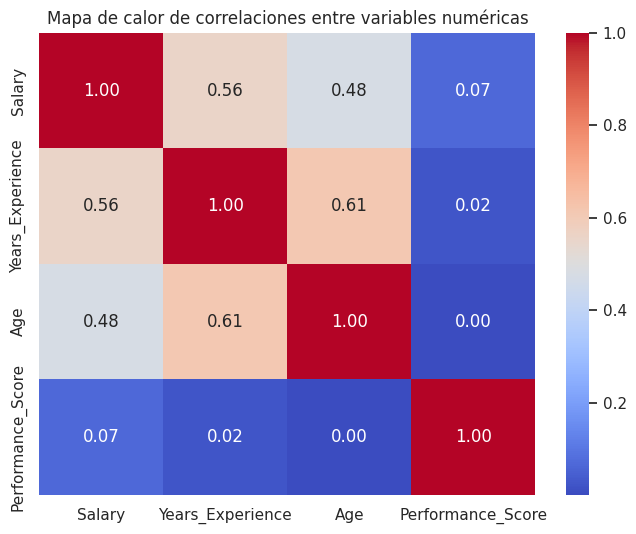

In [ ]:
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones entre variables numéricas')
plt.show()

La matriz de correlación muestra que el salario tiene una relación positiva moderada con los años de experiencia y con la edad. Además, edad y experiencia presentan una correlación positiva, lo cual es esperable. Por otro lado, Performance_Score prácticamente no muestra correlación con las demás variables. Sin embargo, debido a la presencia de valores extremos e inválidos, estas correlaciones deben considerarse preliminares.

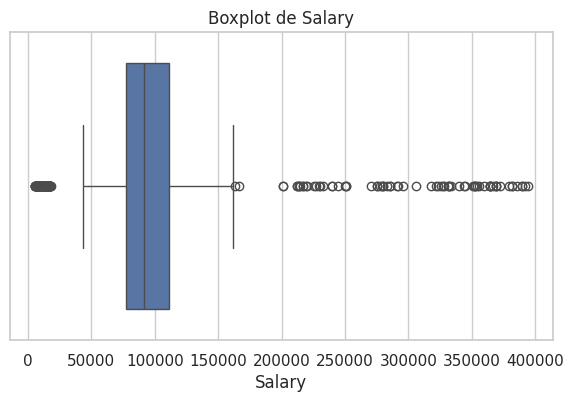

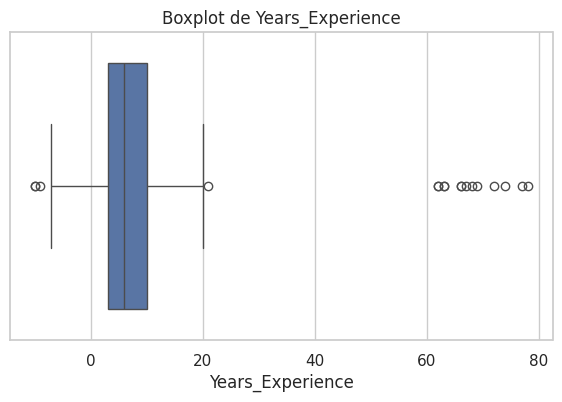

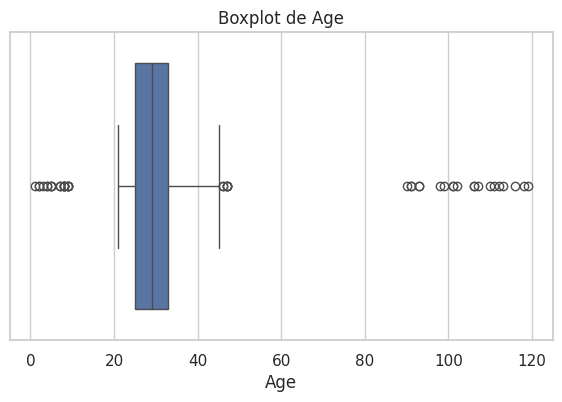

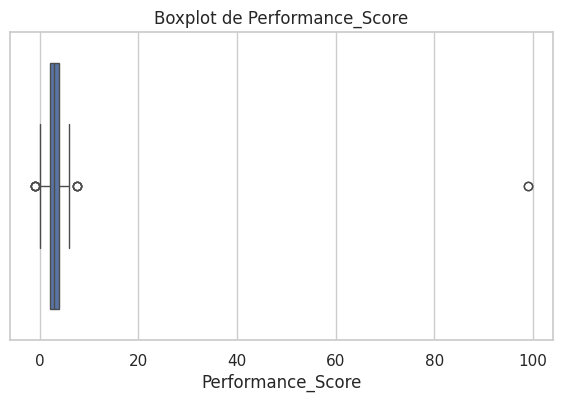

In [ ]:
numeric_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score']

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

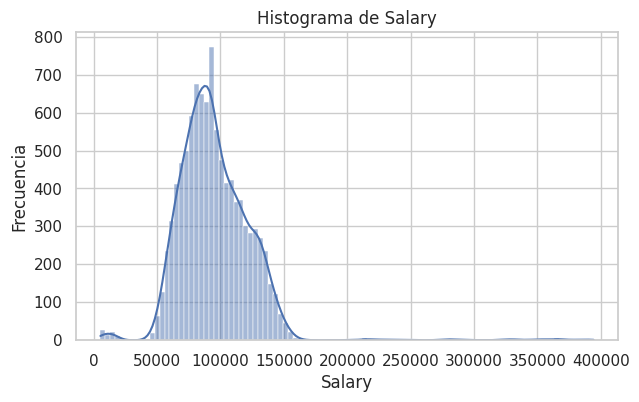

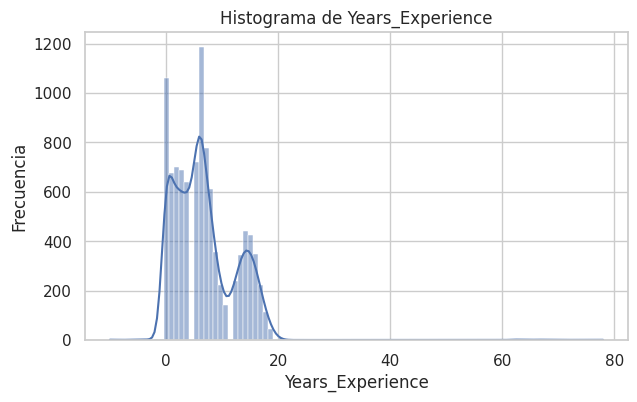

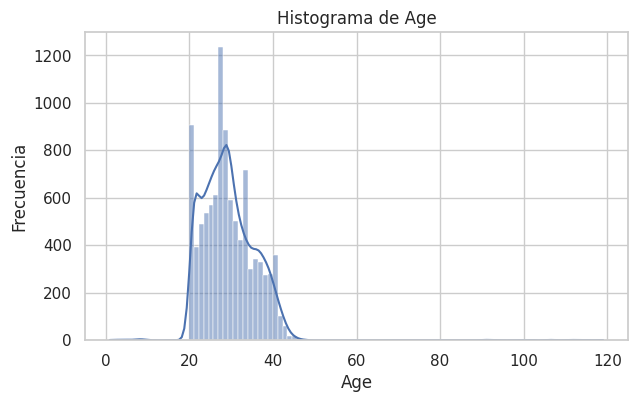

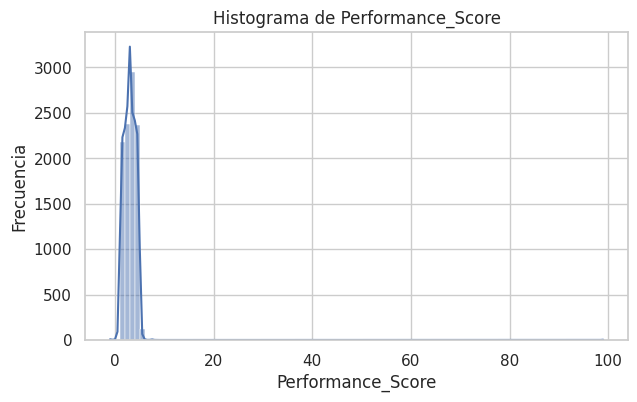

In [ ]:
numeric_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score']

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df_clean[col], bins=100, kde=True)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

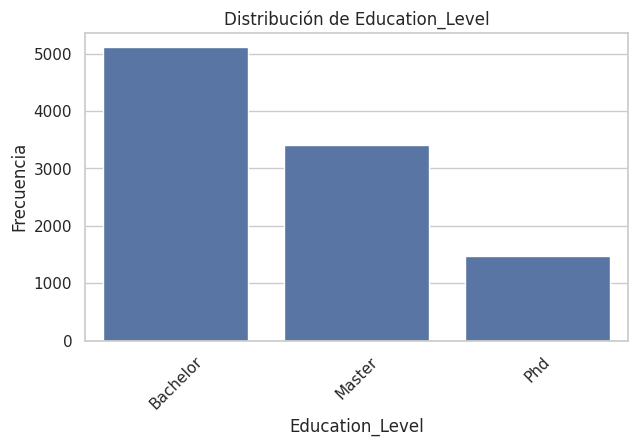

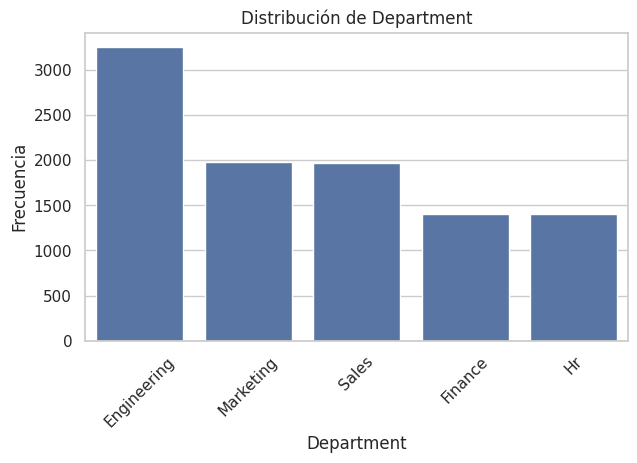

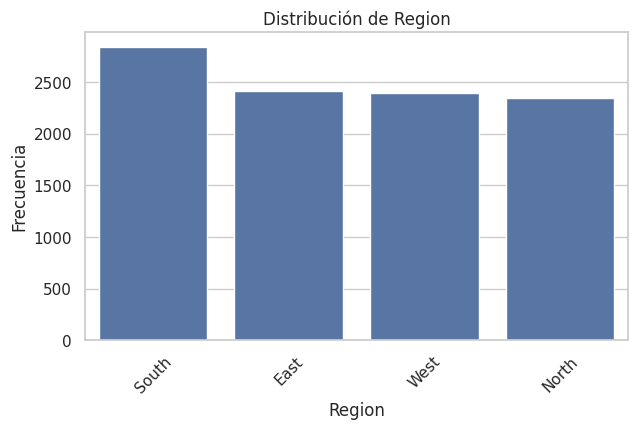

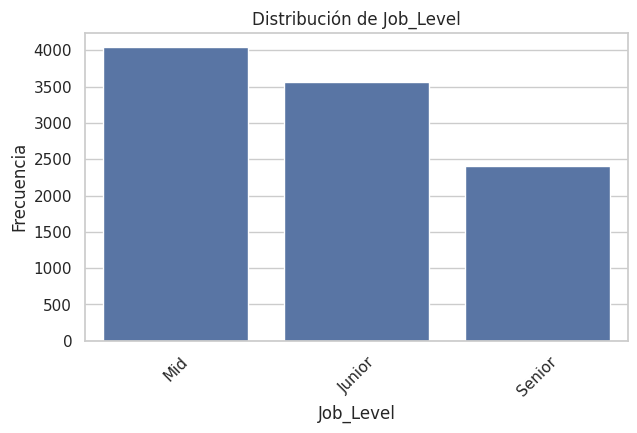

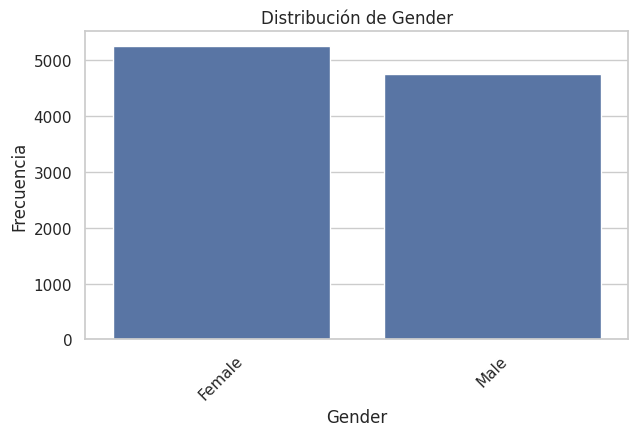

In [ ]:
categorical_cols = ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']

for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df_clean, x=col, order=df_clean[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()

A partir del análisis gráfico inicial, se observa que el dataset presenta una estructura general coherente, especialmente en las variables categóricas, las cuales se encuentran correctamente estandarizadas. Además, se evidencia una relación esperada entre nivel de cargo y salario, donde los cargos Senior presentan mayores remuneraciones que los Mid y Junior. También se observa una relación positiva entre años de experiencia y salario. Sin embargo, el análisis exploratorio permitió identificar valores atípicos e inconsistentes en variables numéricas. En particular, se detectaron años de experiencia negativos o excesivamente altos, edades fuera de un rango laboral razonable y puntajes de desempeño fuera de la escala esperada. Por lo tanto, antes de realizar análisis estadísticos o modelos predictivos, es necesario depurar estas observaciones para evitar sesgos en las conclusiones.

Dataset definitivo

In [ ]:
df_final = df_clean.copy()

In [ ]:
print("Valores problemáticos antes de corregir:")

print("\nYears_Experience menor que 0 o mayor que 50:")
print(((df_final['Years_Experience'] < 0) | (df_final['Years_Experience'] > 50)).sum())

print("\nAge menor que 18 o mayor que 80:")
print(((df_final['Age'] < 18) | (df_final['Age'] > 80)).sum())

print("\nPerformance_Score menor que 1 o mayor que 5:")
print(((df_final['Performance_Score'] < 1) | (df_final['Performance_Score'] > 5)).sum())

Valores problemáticos antes de corregir:

Years_Experience menor que 0 o mayor que 50:
28

Age menor que 18 o mayor que 80:
40

Performance_Score menor que 1 o mayor que 5:
20


In [ ]:
# Years_Experience: no puede ser negativo ni excesivamente alto
df_final.loc[
    (df_final['Years_Experience'] < 0) | (df_final['Years_Experience'] > 50),
    'Years_Experience'
] = np.nan

# Age: rango laboral razonable
df_final.loc[
    (df_final['Age'] < 18) | (df_final['Age'] > 80),
    'Age'
] = np.nan

# Performance_Score: escala esperada de 1 a 5
df_final.loc[
    (df_final['Performance_Score'] < 1) | (df_final['Performance_Score'] > 5),
    'Performance_Score'
] = np.nan

In [ ]:
cols_corregir = ['Years_Experience', 'Age', 'Performance_Score']

for col in cols_corregir:
    mediana = df_final[col].median()
    df_final[col] = df_final[col].fillna(mediana)
    print(f"{col}: valores inválidos reemplazados por la mediana = {mediana}")

Years_Experience: valores inválidos reemplazados por la mediana = 6.0
Age: valores inválidos reemplazados por la mediana = 29.0
Performance_Score: valores inválidos reemplazados por la mediana = 3.0


In [ ]:
# Calcular límites por percentiles
p01 = df_final['Salary'].quantile(0.01)
p99 = df_final['Salary'].quantile(0.99)

print("Percentil 1% de Salary:", p01)
print("Percentil 99% de Salary:", p99)

# Winsorizar Salary
df_final['Salary'] = df_final['Salary'].clip(lower=p01, upper=p99)

print("\nResumen de Salary después de winsorizar:")
print(df_final['Salary'].describe())

Percentil 1% de Salary: 48976.54
Percentil 99% de Salary: 153564.3999999999

Resumen de Salary después de winsorizar:
count     10003.000000
mean      94866.346190
std       23820.516243
min       48976.540000
25%       77300.000000
50%       91732.000000
75%      111451.000000
max      153564.400000
Name: Salary, dtype: float64


In [ ]:
print("Valores faltantes finales:")
print(df_final.isnull().sum())

print("\nDuplicados finales:")
print(df_final.duplicated().sum())

print("\nResumen estadístico final:")
display(df_final.describe())

print("\nInformación final:")
df_final.info()

Valores faltantes finales:
Salary               0
Years_Experience     0
Age                  0
Performance_Score    0
Education_Level      0
Department           0
Region               0
Job_Level            0
Gender               0
dtype: int64

Duplicados finales:
3

Resumen estadístico final:


,Salary,Years_Experience,Age,Performance_Score
count,10003.000000,10003.000000,10003.000000,10003.000000
mean,94866.346190,6.726382,29.351595,3.007068
std,23820.516243,5.096471,5.763593,1.108932
min,48976.540000,0.000000,21.000000,1.000000
25%,77300.000000,3.000000,25.000000,2.100000
50%,91732.000000,6.000000,29.000000,3.000000
75%,111451.000000,10.000000,33.000000,3.900000
max,153564.400000,21.000000,47.000000,5.000000



Información final:
<class 'pandas.core.frame.DataFrame'>
Index: 10003 entries, 0 to 10037
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             10003 non-null  float64
 1   Years_Experience   10003 non-null  float64
 2   Age                10003 non-null  float64
 3   Performance_Score  10003 non-null  float64
 4   Education_Level    10003 non-null  object 
 5   Department         10003 non-null  object 
 6   Region             10003 non-null  object 
 7   Job_Level          10003 non-null  object 
 8   Gender             10003 non-null  object 
dtypes: float64(4), object(5)
memory usage: 781.5+ KB


In [ ]:
# Eliminar duplicados generados después de la imputación/winsorización
df_final = df_final.drop_duplicates()

# Verificar nuevamente
print("Duplicados finales:", df_final.duplicated().sum())
print("Dimensión final:", df_final.shape)

Duplicados finales: 0
Dimensión final: (10000, 9)


In [ ]:
display(df_final.describe())
df_final.info()

,Salary,Years_Experience,Age,Performance_Score
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,94873.717594,6.728200,29.352800,3.006920
std,23819.455437,5.096128,5.763962,1.109051
min,48976.540000,0.000000,21.000000,1.000000
25%,77319.250000,3.000000,25.000000,2.100000
50%,91732.000000,6.000000,29.000000,3.000000
75%,111453.000000,10.000000,33.000000,3.900000
max,153564.400000,21.000000,47.000000,5.000000


<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             10000 non-null  float64
 1   Years_Experience   10000 non-null  float64
 2   Age                10000 non-null  float64
 3   Performance_Score  10000 non-null  float64
 4   Education_Level    10000 non-null  object 
 5   Department         10000 non-null  object 
 6   Region             10000 non-null  object 
 7   Job_Level          10000 non-null  object 
 8   Gender             10000 non-null  object 
dtypes: float64(4), object(5)
memory usage: 781.2+ KB


Luego del proceso de depuración, el dataset final quedó compuesto por 10.000 observaciones y 9 variables. No se registran valores faltantes ni duplicados. Además, las variables numéricas presentan rangos coherentes para el análisis: los años de experiencia varían entre 0 y 21, la edad entre 21 y 47 años, y el puntaje de desempeño entre 1 y 5. Por su parte, la variable salario fue ajustada para reducir el efecto de valores extremos, quedando en un rango entre 48.976 y 153.564. Por lo tanto, la base se encuentra preparada para continuar con el análisis exploratorio y el modelamiento posterior.

Histograma del salario limpio

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(df_final['Salary'], bins=60, kde=True)
plt.title('Histograma del salario depurado')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

NameError: name 'df_final' is not defined

<Figure size 800x500 with 0 Axes>

Boxplot del salario por nivel de cargo limpio

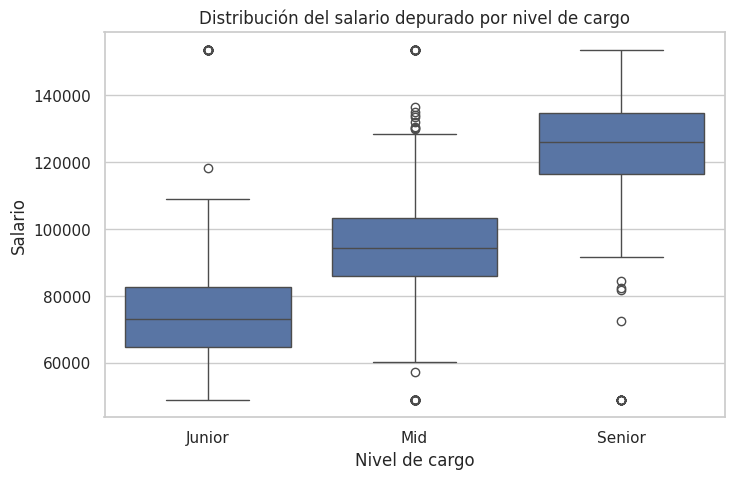

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_final, x='Job_Level', y='Salary')
plt.title('Distribución del salario depurado por nivel de cargo')
plt.xlabel('Nivel de cargo')
plt.ylabel('Salario')
plt.show()

Dispersión experiencia vs salario limpio

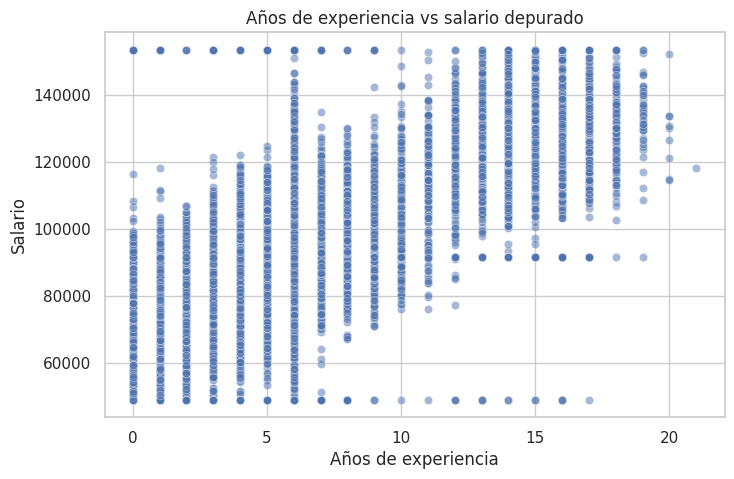

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_final, x='Years_Experience', y='Salary', alpha=0.5)
plt.title('Años de experiencia vs salario depurado')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.show()

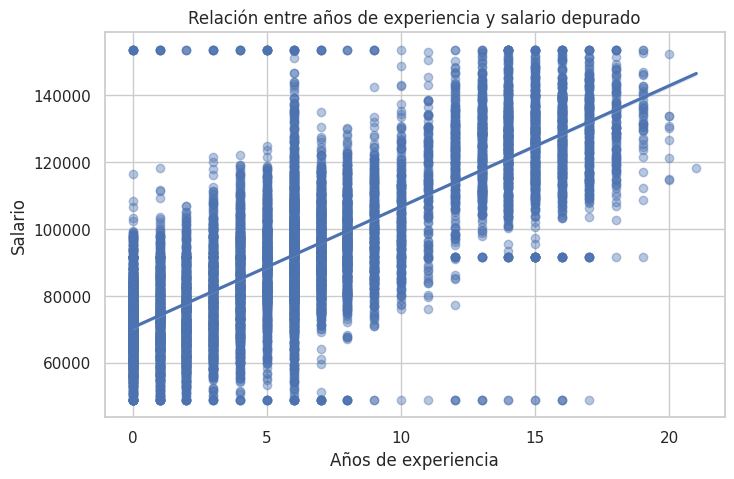

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df_final,
    x='Years_Experience',
    y='Salary',
    scatter_kws={'alpha':0.4}
)
plt.title('Relación entre años de experiencia y salario depurado')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.show()

Salario promedio por departamento limpio

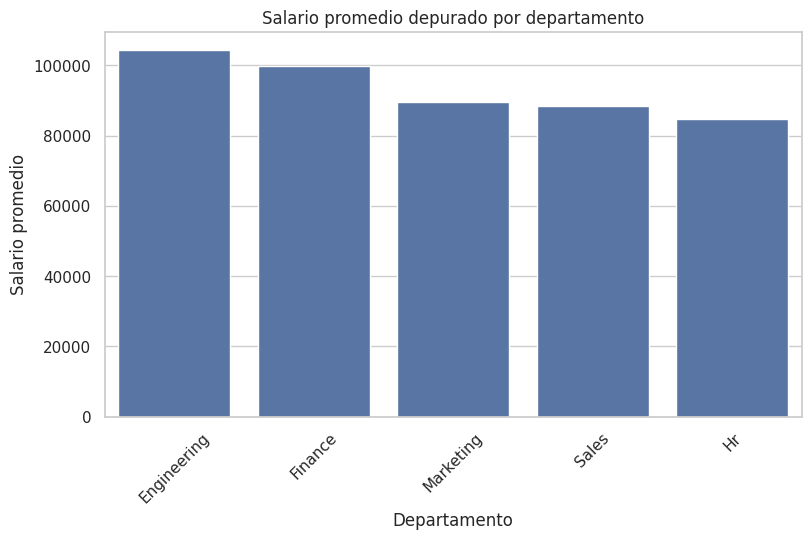

In [ ]:
salary_department = df_final.groupby('Department')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=salary_department.index, y=salary_department.values)
plt.title('Salario promedio depurado por departamento')
plt.xlabel('Departamento')
plt.ylabel('Salario promedio')
plt.xticks(rotation=45)
plt.show()

Mediana del salario por departamento limpio

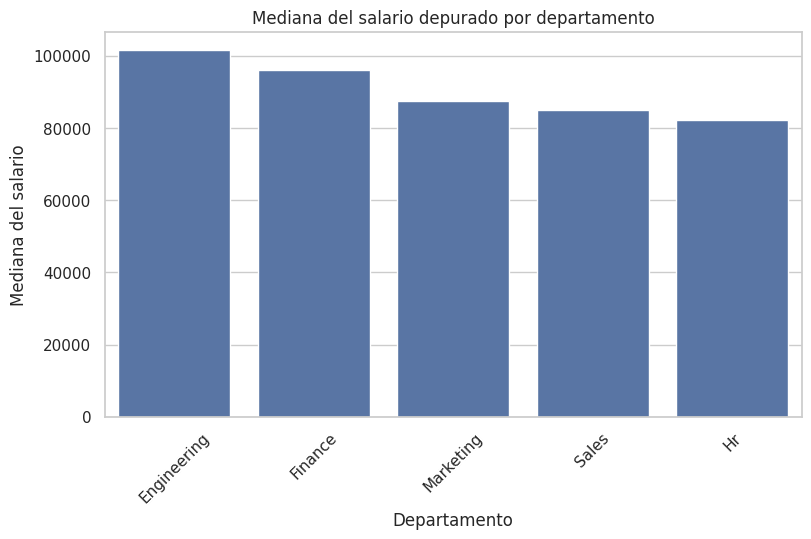

In [ ]:
salary_department_median = df_final.groupby('Department')['Salary'].median().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=salary_department_median.index, y=salary_department_median.values)
plt.title('Mediana del salario depurado por departamento')
plt.xlabel('Departamento')
plt.ylabel('Mediana del salario')
plt.xticks(rotation=45)
plt.show()

Mapa de calor de correlaciones limpio

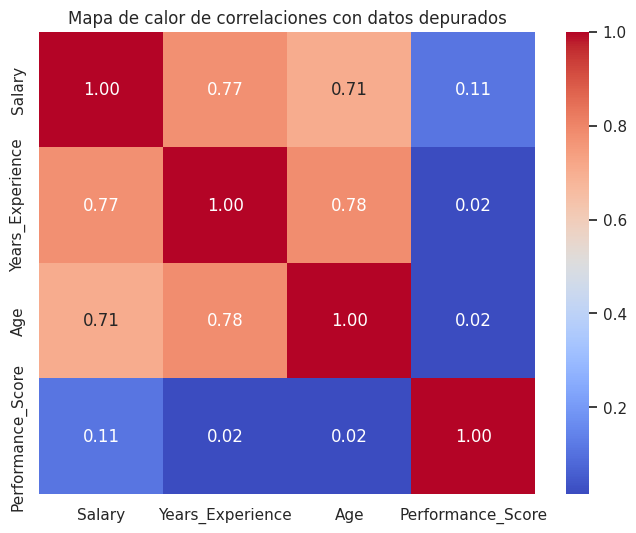

In [ ]:
numeric_df_final = df_final.select_dtypes(include=['int64', 'float64'])

corr_matrix_final = numeric_df_final.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_final, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones con datos depurados')
plt.show()

Boxplots de variables numéricas limpias

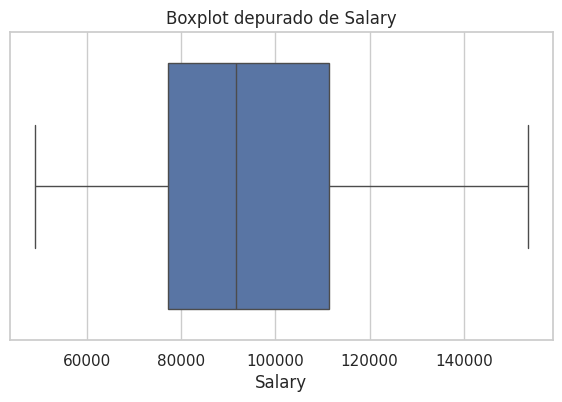

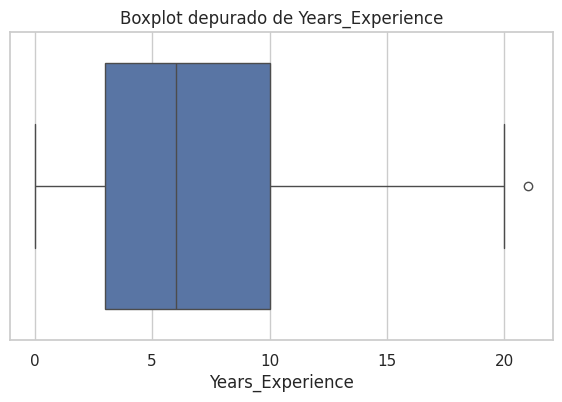

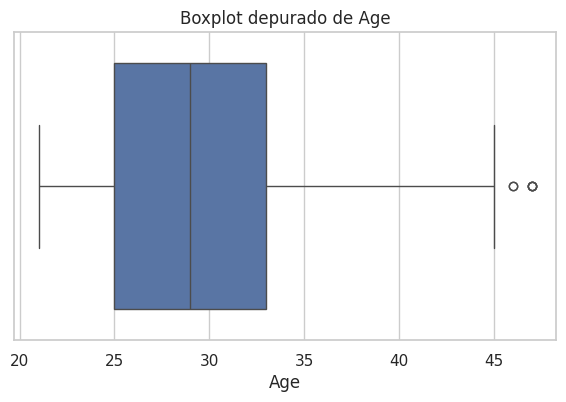

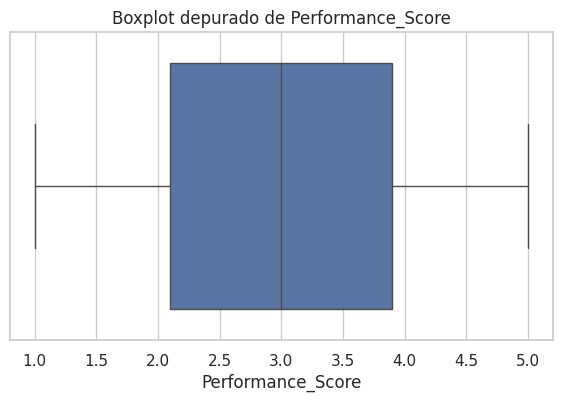

In [ ]:
numeric_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score']

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df_final[col])
    plt.title(f'Boxplot depurado de {col}')
    plt.xlabel(col)
    plt.show()

Histogramas de variables numéricas limpias

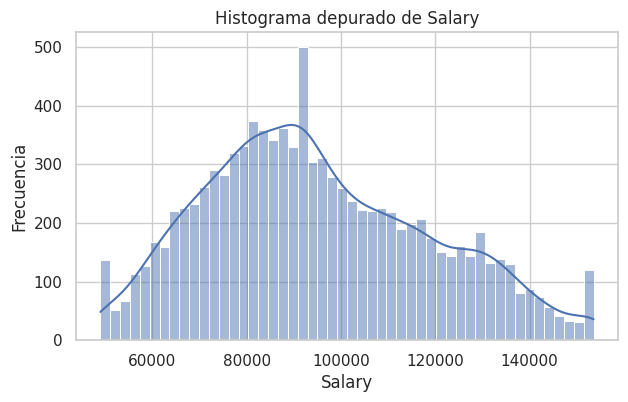

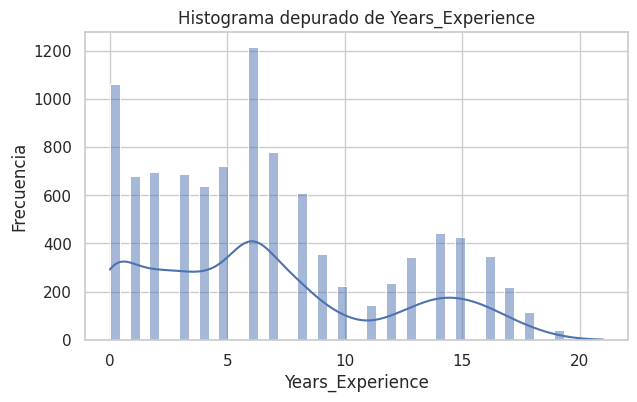

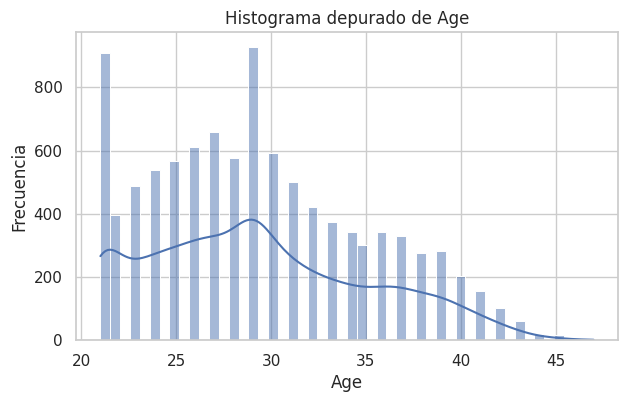

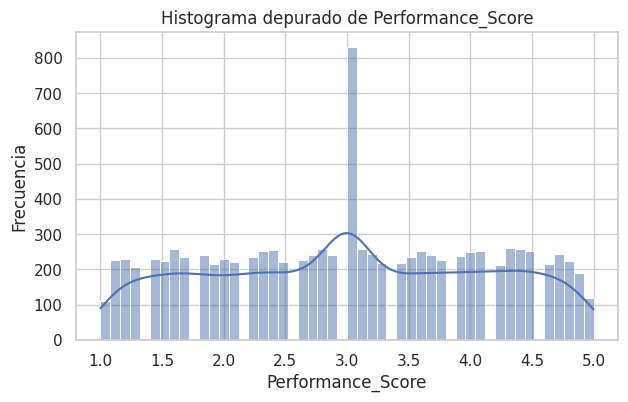

In [ ]:
numeric_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score']

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df_final[col], bins=50, kde=True)
    plt.title(f'Histograma depurado de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

Gráficos categóricos nuevamente

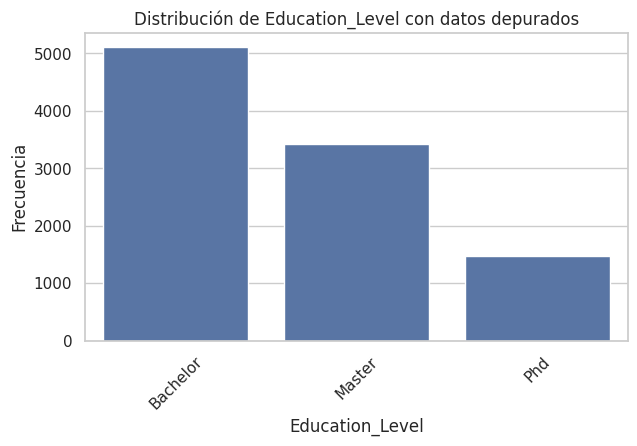

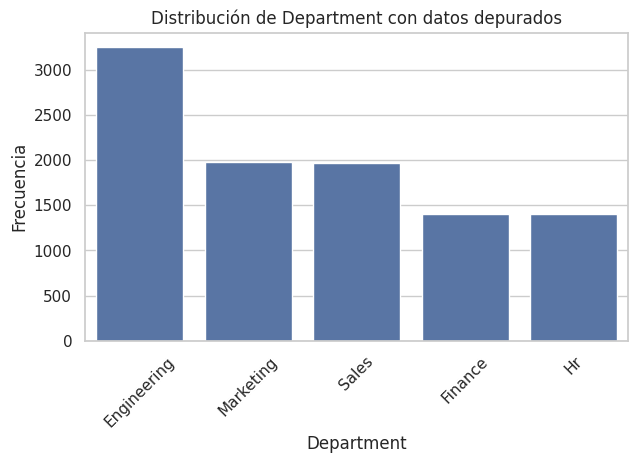

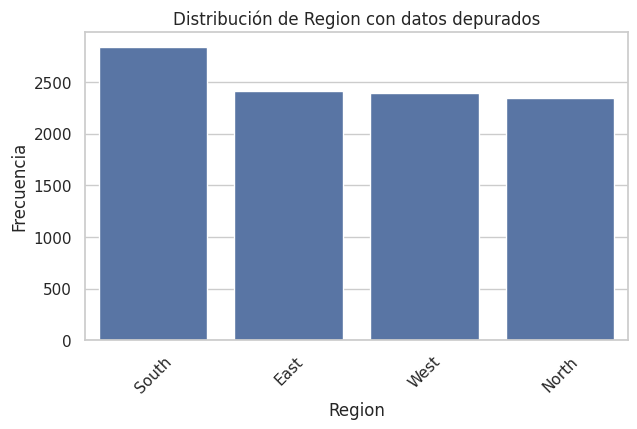

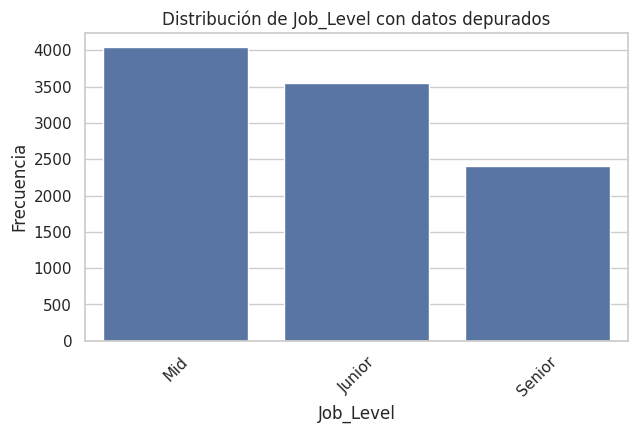

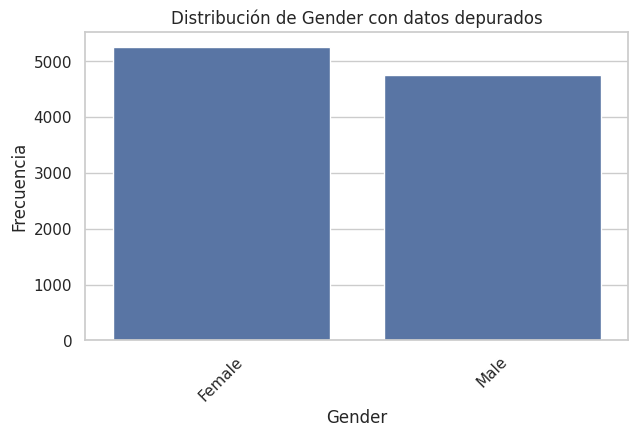

In [ ]:
categorical_cols = ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']

for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df_final, x=col, order=df_final[col].value_counts().index)
    plt.title(f'Distribución de {col} con datos depurados')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()